# 05 Environmental Drift Compensation

Temperature/humidity drift using DHT22-like synthetic data.

The goal is to remove slow nuisance variation without erasing motion events.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)
n_samples = 900
time_min = np.linspace(0, 45, n_samples)

temperature_c = 24.0 + 1.2 * time_min / time_min[-1] + 0.08 * rng.normal(size=n_samples)
humidity_percent = 55.0 - 2.0 * time_min / time_min[-1] + 0.15 * rng.normal(size=n_samples)

motion_event = (time_min > 18) & (time_min < 23)
true_motion = np.zeros(n_samples)
true_motion[motion_event] = 0.18 * np.sin(np.linspace(0, np.pi, motion_event.sum()))

drift = 0.035 * (temperature_c - temperature_c[0]) - 0.012 * (humidity_percent - humidity_percent[0])
raw_feature = 1.0 + drift + true_motion + 0.015 * rng.normal(size=n_samples)

In [2]:
X = np.column_stack([
    np.ones(n_samples),
    temperature_c - temperature_c.mean(),
    humidity_percent - humidity_percent.mean(),
])

# Fit drift only on quiet intervals so motion does not become part of the compensation model.
quiet = ~motion_event
coef, *_ = np.linalg.lstsq(X[quiet], raw_feature[quiet], rcond=None)
estimated_drift = X @ coef
compensated_feature = raw_feature - estimated_drift + estimated_drift[0]

coef

array([ 1.03555728,  0.0397718 , -0.00889221])

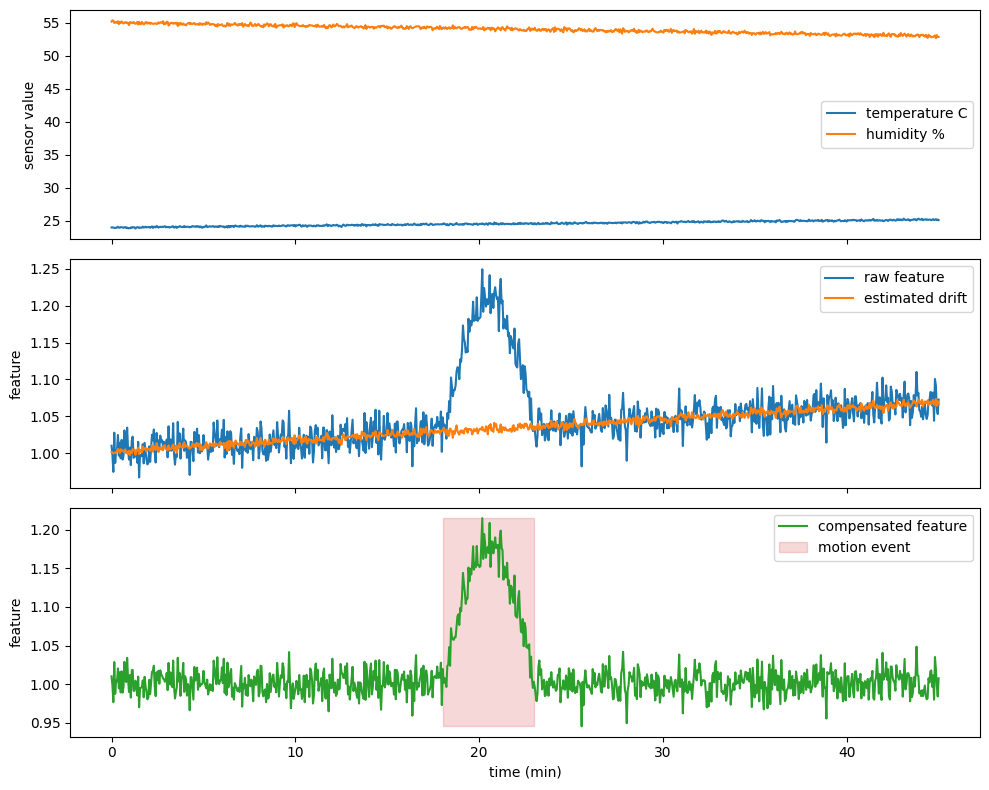

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
axes[0].plot(time_min, temperature_c, label="temperature C")
axes[0].plot(time_min, humidity_percent, label="humidity %")
axes[0].set_ylabel("sensor value")
axes[0].legend()

axes[1].plot(time_min, raw_feature, label="raw feature")
axes[1].plot(time_min, estimated_drift, label="estimated drift")
axes[1].set_ylabel("feature")
axes[1].legend()

axes[2].plot(time_min, compensated_feature, color="tab:green", label="compensated feature")
axes[2].fill_between(time_min, compensated_feature.min(), compensated_feature.max(), where=motion_event, color="tab:red", alpha=0.18, label="motion event")
axes[2].set_xlabel("time (min)")
axes[2].set_ylabel("feature")
axes[2].legend()

fig.tight_layout()
plt.show()